### 1. Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.


In [2]:
import pandas as pd
df = pd.read_csv('clean_telco_churn.csv')

In [3]:
print("Shape:" , df.shape)
print("Coulumn datatypes:" ,df.info())
print("Missing vlaues:" ,df.isnull().sum())

Shape: (7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 n

### 2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

***This is a binary classification problem: predicting whether a given customer will churn (Churn = 1) or stay (Churn = 0), based on their account, service usage, and billing attributes. It matters to the business because retaining an existing customer is significantly cheaper than acquiring a new one — so flagging at-risk customers early lets the company step in with targeted retention offers before they leave.***

### 3. Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any identifier column still present.

In [5]:
y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])

if 'customerID' in X.columns:
    X = X.drop(columns=['customerID'])

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True, dtype=int)


### 4. Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encodingmethod (e.g. one-hot vs. manual mapping).


In [ ]:
categorical_cols = X.select_dtypes(include='object').columns
print(categorical_cols)

### 5. Confirm X contains only numeric columns and has no missing values before moving on.

In [31]:
print("X shape:", X.shape, "| y shape:", y.shape)
print("Missing in X:", X.isnull().sum().sum())
X.head()

X shape: (7043, 30) | y shape: (7043,)
Missing in X: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


### 6. Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you found about the target's class balance in Lab 2?

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

### 7. Report the shape of X_train, X_test, y_train, and y_test.

In [7]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


### 8. Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate predictions on both the training and test sets

In [9]:
from sklearn.tree import DecisionTreeClassifier

model_train = DecisionTreeClassifier(random_state=42)
model_train.fit(X_train, y_train)

y_hat_train = model_train.predict(X_train)
y_hat_test = model_train.predict(X_test)

### 9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [10]:
depth = model_train.get_depth()
print("Baseline Tree Depth:", depth)

Baseline Tree Depth: 23


***The baseline tree grew to a depth of 23. Yes, this is surprising because we only have 30 features. Without any restrictions, the tree splits until almost every single training sample is in its own leaf, which means it is memorizing training noise instead of learning general patterns.***


### 10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

base_acc = accuracy_score(y_test, y_hat_test)
base_prec = precision_score(y_test, y_hat_test)
base_rec = recall_score(y_test, y_hat_test)
base_f1 = f1_score(y_test, y_hat_test)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [base_acc, base_prec, base_rec, base_f1]
})
print("Test Set Metrics:")
display(metrics_df.round(4))

Test Set Metrics:


,Metric,Score
0,Accuracy,0.7260
1,Precision,0.4838
2,Recall,0.4786
3,F1-Score,0.4812


### 11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?


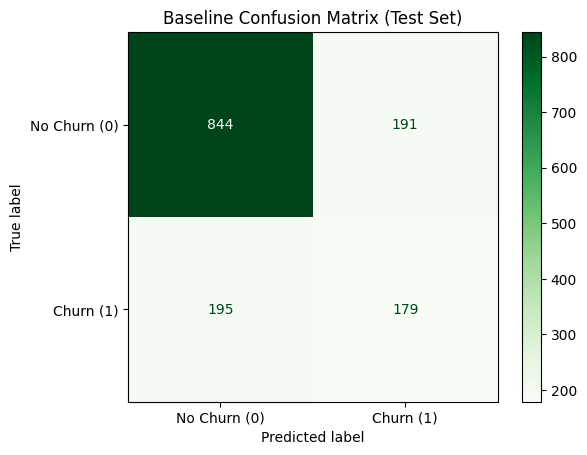

Correctly caught churners (TP): 179
Missed churners (FN): 195
False alarms (FP): 191
Correctly identified non-churners (TN): 844


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_base = confusion_matrix(y_test, y_hat_test)
tn, fp, fn, tp = cm_base.ravel()

ConfusionMatrixDisplay(cm_base, display_labels=['No Churn (0)', 'Churn (1)']).plot(cmap='Greens')
plt.title("Baseline Confusion Matrix (Test Set)")
plt.grid(False)
plt.show()

print(f"Correctly caught churners (TP): {tp}")
print(f"Missed churners (FN): {fn}")
print(f"False alarms (FP): {fp}")
print(f"Correctly identified non-churners (TN): {tn}")

***Out of 374 actual churners, the model correctly caught 179, but missed 195(over 52% missed). It also had 191 false alarms.***

### 12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

***Accuracy is deceptive here because the dataset is imbalanced (73.5% non-churners). A dummy model predicting 'No Churn' for everyone would get 73.5% accuracy but catch 0 churners. Recall and F1-Score are the most trustworthy metrics because our goal is to catch churners (minimizing false negatives) without too many false alarms.***

### 13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?

In [17]:
tr_acc = accuracy_score(y_train, y_hat_train)
te_acc = accuracy_score(y_test, y_hat_test)
print(f"Train Accuracy: {tr_acc:.4f}")
print(f"Test Accuracy:  {te_acc:.4f}")
print(f"Gap:            {tr_acc - te_acc:.4f}")


Train Accuracy: 0.9980
Test Accuracy:  0.7260
Gap:            0.2720


***The baseline tree has a 99.8% train accuracy vs 72.6% test accuracy — a massive gap of 27.2%, which clearly shows severe overfitting.***

### 14. Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.


In [18]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
depth_labels = [str(d) if d is not None else 'None (23)' for d in depths]
records = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    r_tr = accuracy_score(y_train, clf.predict(X_train))
    r_te = accuracy_score(y_test, clf.predict(X_test))
    r_f1 = f1_score(y_test, clf.predict(X_test))
    records.append({'max_depth': str(d) if d else 'None', 'Train Acc': r_tr, 'Test Acc': r_te, 'Test F1': r_f1, 'Gap': r_tr - r_te})

results_df = pd.DataFrame(records)
display(results_df.round(4))

,max_depth,Train Acc,Test Acc,Test F1,Gap
0,2,0.7911,0.7871,0.4949,0.0040
1,3,0.7911,0.7871,0.4949,0.0040
2,4,0.7925,0.7956,0.5714,-0.0031
3,5,0.8023,0.7942,0.5821,0.0081
4,6,0.8106,0.8006,0.5697,0.0100
5,8,0.8358,0.7828,0.5831,0.0530
6,10,0.8727,0.7551,0.5293,0.1176
7,None,0.9980,0.7260,0.4812,0.2720


### 15. Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

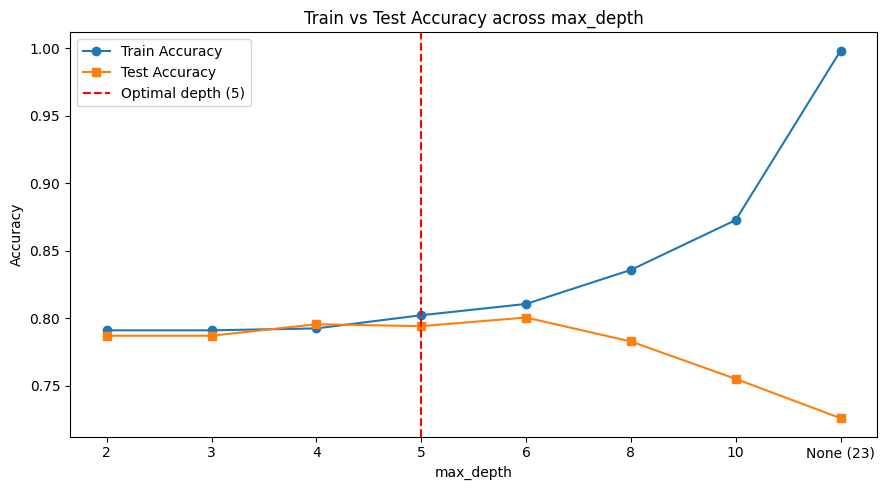

In [20]:
plt.figure(figsize=(9, 5))
plt.plot(range(len(depth_labels)), [r['Train Acc'] for r in records], marker='o', label='Train Accuracy')
plt.plot(range(len(depth_labels)), [r['Test Acc'] for r in records], marker='s', label='Test Accuracy')
plt.axvline(x=3, color='red', linestyle='--', label='Optimal depth (5)')
plt.xticks(ticks=range(len(depth_labels)), labels=depth_labels)
plt.title("Train vs Test Accuracy across max_depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


***In the plot, both train and test accuracy rise together up to depth 4–5. Around depth 5–6, test accuracy peaks at ~80% and then starts falling as depth increases to 8, 10, and None, while train accuracy keeps climbing toward 100%. This divergence shows the model starts overfitting past depth 5–6.***

### 16. Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.



***We choose max_depth = 5. It gives near-peak test accuracy (79.4%), the highest test F1-score (0.582), and a very small train-test gap of only 0.8%. Deeper trees just overfit to the training set***

### 17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison against the baseline.



In [21]:
dt_best = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
dt_best.fit(X_train, y_train)
y_pred_best = dt_best.predict(X_test)

### 18. Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and report its full evaluation metrics (as in Part 5) for comparison against the baseline.



,Model,Test Acc,Test Precision,Test Recall,Test F1
0,"Baseline (Depth 23, Gini)",0.7260,0.4838,0.4786,0.4812
1,"Tuned (Depth 5, Gini)",0.7942,0.6312,0.5401,0.5821
2,"Tuned (Depth 5, Entropy)",0.7921,0.6484,0.4733,0.5471


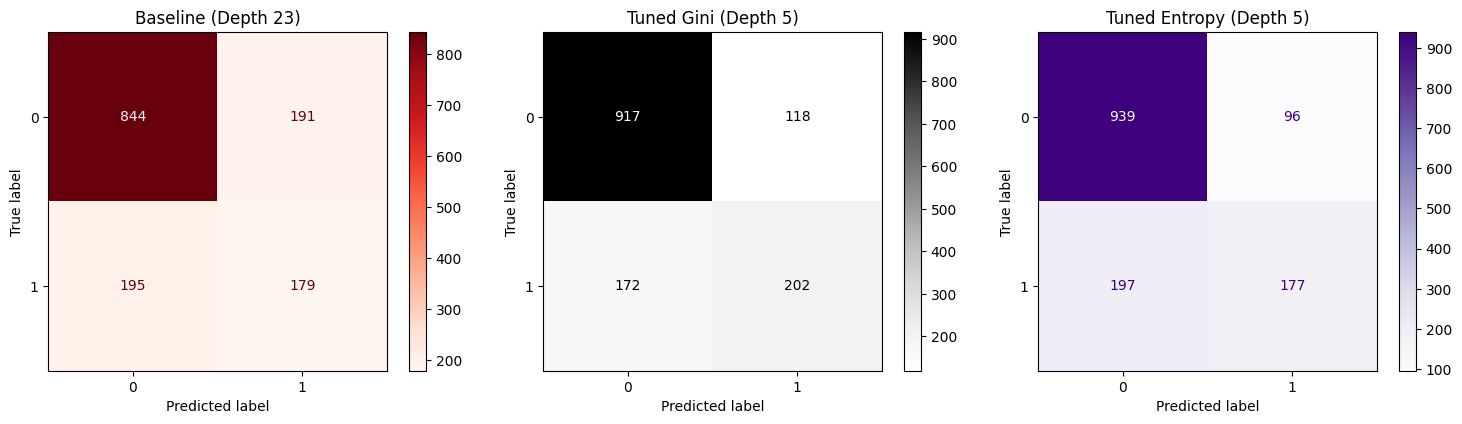

In [25]:
dt_ent = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
dt_ent.fit(X_train, y_train)
y_pred_ent = dt_ent.predict(X_test)

comp_df = pd.DataFrame({
    'Model': ['Baseline (Depth 23, Gini)', 'Tuned (Depth 5, Gini)', 'Tuned (Depth 5, Entropy)'],
    'Test Acc': [base_acc, accuracy_score(y_test, y_pred_best), accuracy_score(y_test, y_pred_ent)],
    'Test Precision': [base_prec, precision_score(y_test, y_pred_best), precision_score(y_test, y_pred_ent)],
    'Test Recall': [base_rec, recall_score(y_test, y_pred_best), recall_score(y_test, y_pred_ent)],
    'Test F1': [base_f1, f1_score(y_test, y_pred_best), f1_score(y_test, y_pred_ent)],
})
display(comp_df.round(4))

# Confusion matrices comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ConfusionMatrixDisplay(cm_base).plot(ax=axes[0], cmap='Reds')
axes[0].set_title("Baseline (Depth 23)")
axes[0].grid(False)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best)).plot(ax=axes[1], cmap='Greys')
axes[1].set_title("Tuned Gini (Depth 5)")
axes[1].grid(False)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ent)).plot(ax=axes[2], cmap='Purples')
axes[2].set_title("Tuned Entropy (Depth 5)")
axes[2].grid(False)

plt.tight_layout()
plt.show()


***Comparison Notes:***

***Tuned Gini at depth 5 improves accuracy from 72.6% to 79.4% and F1 from 0.481 to 0.582, catching 202 churners instead of 179 and cutting false alarms from 191 down to 118. Gini and Entropy have similar accuracy, but Gini achieves higher recall (54.0% vs 47.3%), making it the better choice for churn detection.***

### 19. Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most?


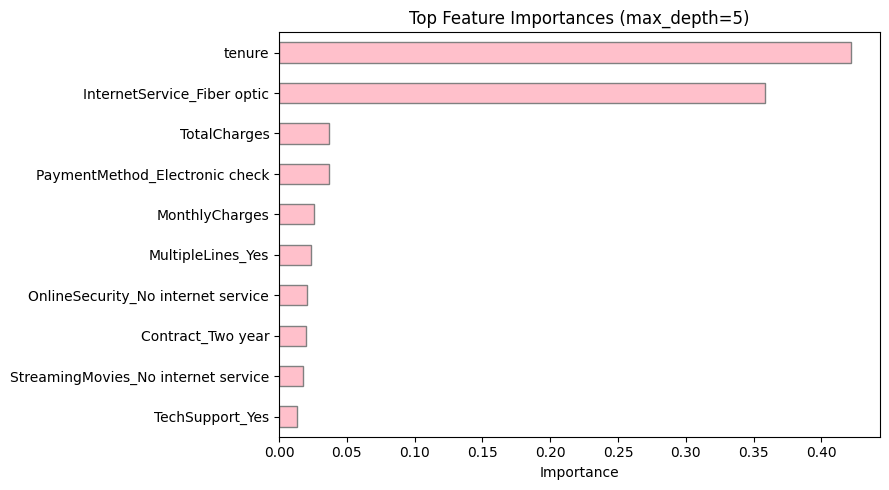

Top 5 features:
tenure                            0.4220
InternetService_Fiber optic       0.3581
TotalCharges                      0.0372
PaymentMethod_Electronic check    0.0368
MonthlyCharges                    0.0255
dtype: float64


In [27]:
feat_imp = pd.Series(dt_best.feature_importances_, index=X.columns).sort_values(ascending=True)
top_imp = feat_imp[feat_imp > 0.01]

plt.figure(figsize=(9, 5))
top_imp.plot(kind='barh', color='pink', edgecolor='grey')
plt.title("Top Feature Importances (max_depth=5)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(feat_imp.sort_values(ascending=False).head(5).round(4))


### 20. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?


***The top features agree with what we found in Lab 2's EDA:***

***1. tenure (~42.2%): In Lab 2, we noticed new customers had by far the highest churn rate, while long-term customers rarely left.***

***2. InternetService_Fiber optic (35.8%):Fiber optic subscribers had a surprisingly high churn rate (41%) in our bivariate analysis, likely due to high prices or service complaints.***

***3. PaymentMethod_Electronic check & charges:Customers paying via electronic check churned much more than those on auto-debit, and higher monthly charges also correlated with leaving***

### 21. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?


***We selected the pruned Decision Tree with max_depth = 5 using Gini. It achieved 79.4% test accuracy and an F1-score of 0.582, which is a big improvement over the baseline tree (72.6% accuracy, 0.481 F1) and completely eliminated the 27.2% overfitting gap. Its main limitations are that decision trees only make perpendicular axis splits, small changes in the dataset can change the tree structure, and recall is still moderate (54%), meaning some churners are still missed due to class imbalance.***

### 22. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.


***If we had more time, we would:***
***1. Try ensemble algorithms like Random Forest or XGBoost to reduce variance and improve recall.***

***2. Address class imbalance using SMOTE or setting class_weight='balanced'.***

***3. Engineer new features, such as tenure-to-monthly charges ratio or contract tenure remaining.***

***4. Tune the classification probability threshold instead of the default 0.5 to catch more churners. ***


### 23. Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries — write your own entropy and information gain functions. Print the gain values for each attribute at every split.


In [30]:
import numpy as np
# Play Badminton dataset
badminton_data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df_badminton = pd.DataFrame(badminton_data)
display(df_badminton)

# Entropy
def entropy(s):
    counts = s.value_counts()
    probs = counts / len(s)
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

# Information Gain
def info_gain(df, attr, target='Play'):
    tot_ent = entropy(df[target])
    vals, counts = np.unique(df[attr], return_counts=True)
    w_ent = np.sum([(counts[i]/len(df)) * entropy(df[df[attr] == vals[i]][target]) for i in range(len(vals))])
    return tot_ent - w_ent

# ID3 recursive tree builder
def id3(df, orig_df, features, target='Play', depth=0):
    indent = "  " * depth
    if len(np.unique(df[target])) <= 1:
        leaf = np.unique(df[target])[0]
        print(f"{indent}-> Leaf: {leaf}")
        return leaf
    elif len(df) == 0:
        return np.unique(orig_df[target])[np.argmax(orig_df[target].value_counts())]
    elif len(features) == 0:
        return np.unique(df[target])[np.argmax(df[target].value_counts())]

    print(f"{indent}[Depth {depth}] (Samples: {len(df)})")
    gains = {}
    for feat in features:
        g = info_gain(df, feat, target)
        gains[feat] = g
        print(f"{indent}  Gain({feat}) = {g:.4f}")

    best = max(gains, key=gains.get)
    print(f"{indent}  => Best Split: {best} (Gain = {gains[best]:.4f})\n")

    tree = {best: {}}
    rem_features = [f for f in features if f != best]

    for val in sorted(np.unique(df[best])):
        sub_df = df[df[best] == val]
        print(f"{indent}Branch [{best} = {val}]:")
        subtree = id3(sub_df, orig_df, rem_features, target, depth + 1)
        tree[best][val] = subtree
    return tree

print("--- ID3 Tree Induction ---")
tree = id3(df_badminton, df_badminton, ['Outlook', 'Temperature', 'Humidity', 'Wind'], 'Play')

import pprint
print("\nFinal Tree:")
pprint.pprint(tree)

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


--- ID3 Tree Induction ---
[Depth 0] (Samples: 14)
  Gain(Outlook) = 0.2467
  Gain(Temperature) = 0.0292
  Gain(Humidity) = 0.1518
  Gain(Wind) = 0.0481
  => Best Split: Outlook (Gain = 0.2467)

Branch [Outlook = Overcast]:
  -> Leaf: Yes
Branch [Outlook = Rain]:
  [Depth 1] (Samples: 5)
    Gain(Temperature) = 0.0200
    Gain(Humidity) = 0.0200
    Gain(Wind) = 0.9710
    => Best Split: Wind (Gain = 0.9710)

  Branch [Wind = Strong]:
    -> Leaf: No
  Branch [Wind = Weak]:
    -> Leaf: Yes
Branch [Outlook = Sunny]:
  [Depth 1] (Samples: 5)
    Gain(Temperature) = 0.5710
    Gain(Humidity) = 0.9710
    Gain(Wind) = 0.0200
    => Best Split: Humidity (Gain = 0.9710)

  Branch [Humidity = High]:
    -> Leaf: No
  Branch [Humidity = Normal]:
    -> Leaf: Yes

Final Tree:
{'Outlook': {'Overcast': 'Yes',
             'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}},
             'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}
